# Stage 1 Teff Model (190 features) — Results Viewer

Displays results from the Stage 1 Teff model trained by `run_training_teff_190.py`.
No training is performed here — model weights and scaler are loaded from disk.

**New vs baseline**: 171 color features → **190 features** (171 colors + 19 absolute magnitudes).

**Baseline to beat**: 171-feature Teff ANN — R² = 0.965, RMSE = 144 K

**Expected artifacts**:
- `models/teff_190/stellar_teff_190feat_best.pth`
- `models/teff_190/scaler_teff_190.pkl`
- `results/teff_190/test_metrics.json`
- `results/teff_190/*.png`

## 1. Imports & Configuration

In [2]:
import pandas as pd

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_context('talk')

DEVICE = torch.device('cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cpu


## 2. Paths

In [4]:
PROJECT_ROOT = Path('C:/git_repo/cool-dwarf_stellar_parameter_inference_from_survey_data')
DATA_PATH    = PROJECT_ROOT / 'data' / 'logg_final_df' / 'cool_dwarf_catalog_FGKM_consolidated.csv'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'teff_190'
MODELS_DIR   = PROJECT_ROOT / 'models'  / 'teff_190'
MODEL_PATH   = MODELS_DIR / 'stellar_teff_190feat_best.pth'
SCALER_PATH  = MODELS_DIR / 'scaler_teff_190.pkl'
METRICS_PATH = RESULTS_DIR / 'test_metrics.json'

print(f'Model:   {MODEL_PATH}')
print(f'Scaler:  {SCALER_PATH}')
print(f'Metrics: {METRICS_PATH}')

Model:   C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\teff_190\stellar_teff_190feat_best.pth
Scaler:  C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\teff_190\scaler_teff_190.pkl
Metrics: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\teff_190\test_metrics.json


## 3. Data Loading & Feature Engineering (190 features)

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape}')

sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP',
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H',
    'A_KS', 'A_W1', 'A_W2'
]
COLOR_COLS   = [f'COLOR_{sorted_mags[i]}_{sorted_mags[j]}'
                for i in range(len(sorted_mags)) for j in range(i+1, len(sorted_mags))]
ABS_MAG_COLS = [b.replace('A_', 'M_') for b in sorted_mags]

dist_pc     = df['distance_gaia_pc'].values.astype(np.float64)
dist_mod    = 5.0 * np.log10(dist_pc / 10.0)
abs_mag_arr = np.column_stack([df[b].values - dist_mod for b in sorted_mags]).astype(np.float32)

FEATURE_COLS = COLOR_COLS + ABS_MAG_COLS    # 190
color_arr    = df[COLOR_COLS].values.astype(np.float32)
X            = np.hstack([color_arr, abs_mag_arr])

y              = np.log10(df['teff'].values).astype(np.float32)
spectral_types = df['spectral_type_group'].values

print(f'Features: {X.shape[1]}  ({len(COLOR_COLS)} colors + {len(ABS_MAG_COLS)} abs mags)')

Dataset: (904427, 197)
Features: 190  (171 colors + 19 abs mags)


## 4. Train / Val / Test Split

In [6]:
from sklearn.model_selection import train_test_split

_, X_temp, _, y_temp, _, st_temp = train_test_split(
    X, y, spectral_types, test_size=0.30, random_state=SEED, stratify=spectral_types)
_, X_test, _, y_test, _, st_test = train_test_split(
    X_temp, y_temp, st_temp, test_size=0.50, random_state=SEED, stratify=st_temp)

print(f'Test set: {X_test.shape[0]:,} samples')

Test set: 135,665 samples


## 5. Load Saved Scaler

In [7]:
scaler       = joblib.load(SCALER_PATH)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
print(f'Loaded scaler. X_test_scaled: {X_test_scaled.shape}')

Loaded scaler. X_test_scaled: (135665, 190)


## 6. Test DataLoader

In [8]:
class StellarDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets,  dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

test_loader = DataLoader(StellarDataset(X_test_scaled, y_test),
                         batch_size=2048, shuffle=False, num_workers=0)
print(f'Test DataLoader: {len(test_loader)} batches')

Test DataLoader: 67 batches


## 7. Model Architecture

```
190 → Linear(256) → BN → ReLU → Dropout(0.15)
    → Linear(128) → BN → ReLU → Dropout(0.15)
    → Linear(64)  → BN → ReLU → Dropout(0.10)
    → Linear(32)  → BN → ReLU → Dropout(0.10)
    → Linear(1)
```

In [9]:
class StellarTeffNet190(nn.Module):
    def __init__(self, input_dim, dropout_h1=0.15, dropout_h2=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_h1),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_h1),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout_h2),
            nn.Linear(64,  32),        nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(dropout_h2),
            nn.Linear(32,  1),
        )
    def forward(self, x): return self.net(x).squeeze(1)

model = StellarTeffNet190(input_dim=len(FEATURE_COLS)).to(DEVICE)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

StellarTeffNet190(
  (net): Sequential(
    (0): Linear(in_features=190, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parameters: 93,121


## 8. Load Saved Model

In [10]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded model from: {MODEL_PATH}')
print(f'  Best epoch:    {checkpoint["best_epoch"]}')
print(f'  Best val loss: {checkpoint["best_val_loss"]:.8f}')

Loaded model from: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\teff_190\stellar_teff_190feat_best.pth
  Best epoch:    10
  Best val loss: 0.00013803


## 9. Training Diagnostics

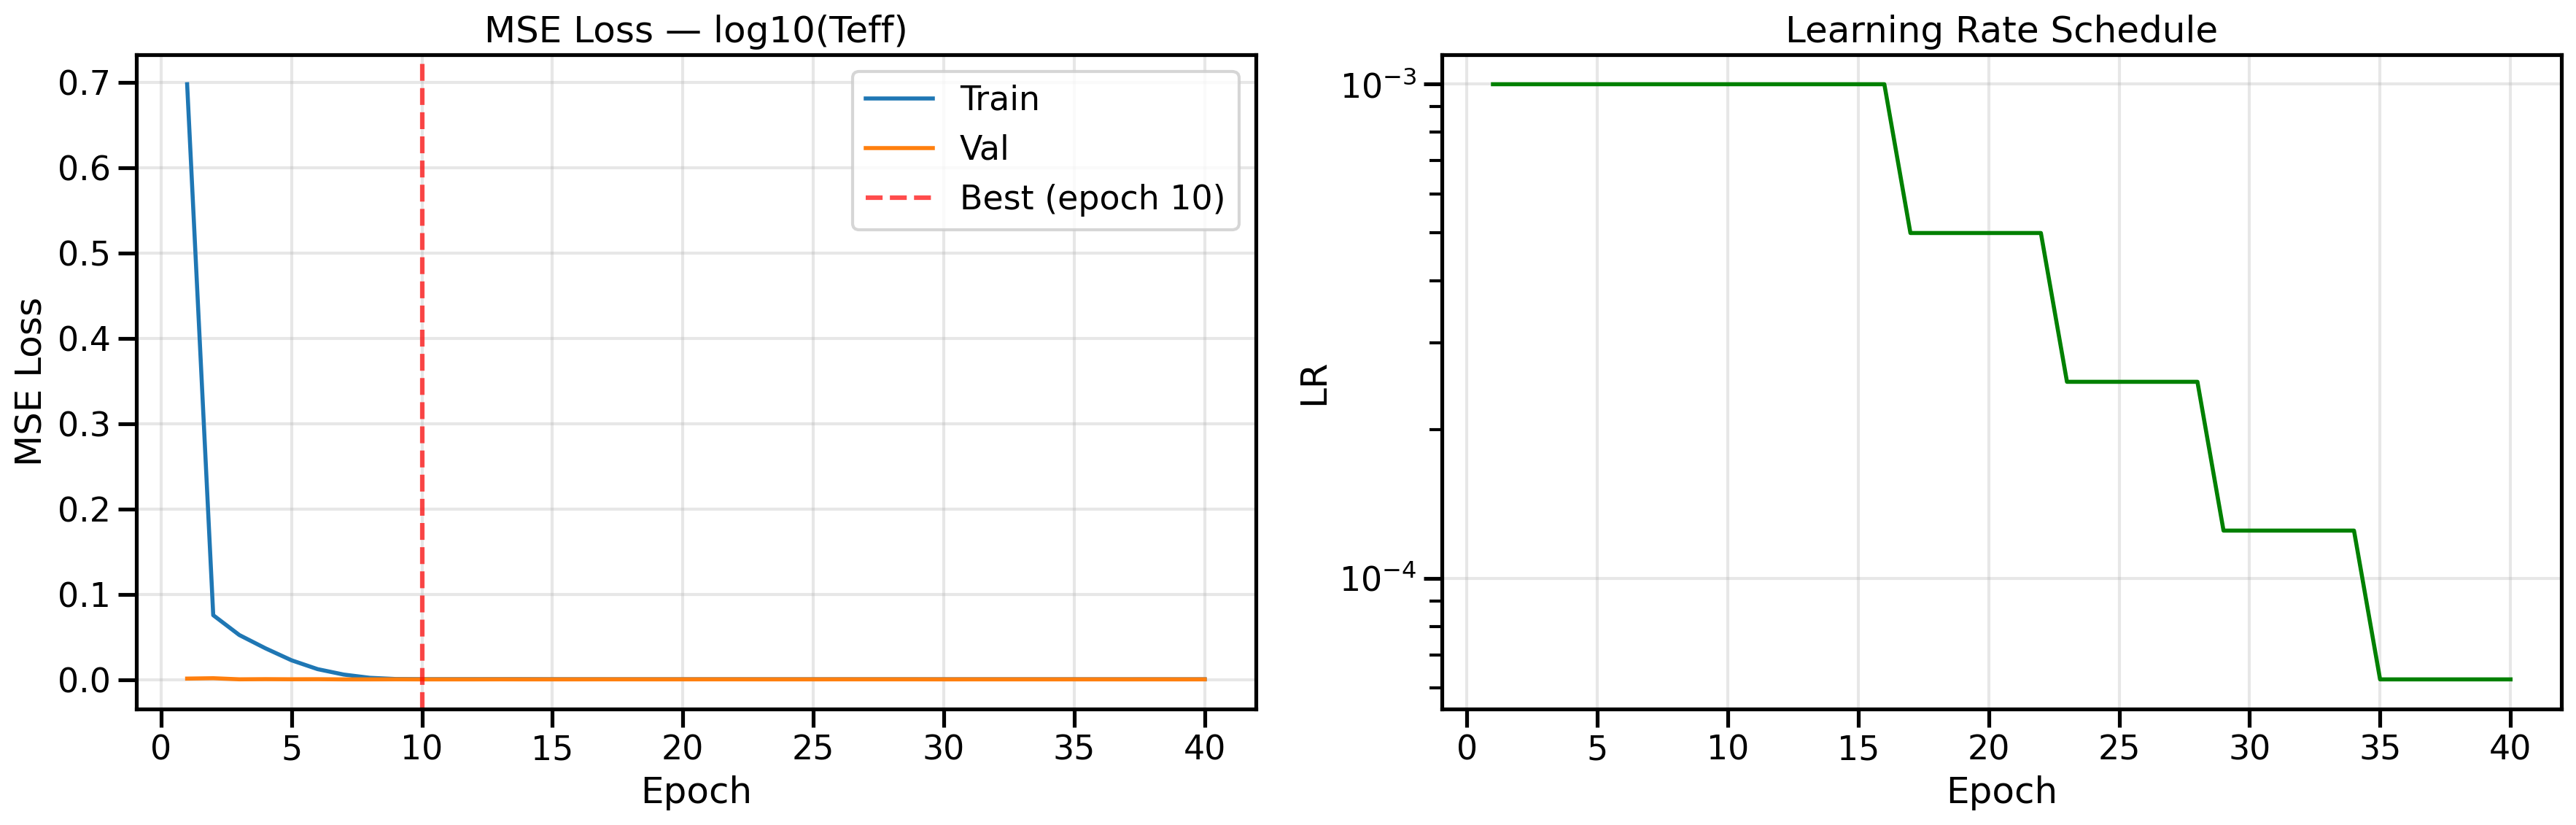

In [11]:
from IPython.display import Image as IPyImage, display as ipy_display
diag = RESULTS_DIR / 'training_diagnostics.png'
if diag.exists():
    ipy_display(IPyImage(filename=str(diag), width=1400))
else:
    print(f'Not found: {diag}  — run run_training_teff_190.py first.')

## 10. Test Set Evaluation

In [12]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        all_preds.append(model(X_b.to(DEVICE)).cpu().numpy())
        all_targets.append(y_b.numpy())

log10_teff_pred = np.concatenate(all_preds)
log10_teff_true = np.concatenate(all_targets)
teff_pred_K     = 10.0 ** log10_teff_pred
teff_true_K     = 10.0 ** log10_teff_true

rmse_teff     = np.sqrt(mean_squared_error(teff_true_K, teff_pred_K))
mae_teff      = mean_absolute_error(teff_true_K, teff_pred_K)
r2_teff       = r2_score(teff_true_K, teff_pred_K)
r2_log10_teff = r2_score(log10_teff_true, log10_teff_pred)

print('=' * 60)
print('  TEST SET — Teff ANN (190 features)')
print('=' * 60)
print(f'  RMSE:       {rmse_teff:.2f} K')
print(f'  MAE:        {mae_teff:.2f} K')
print(f'  R² (K):     {r2_teff:.5f}')
print(f'  R² (log10): {r2_log10_teff:.5f}')
print()
print(f'  Per-type breakdown:')
for stype in ['F','G','K','M']:
    mask = st_test == stype
    if not mask.any(): continue
    tr2  = r2_score(teff_true_K[mask], teff_pred_K[mask])
    trms = np.sqrt(mean_squared_error(teff_true_K[mask], teff_pred_K[mask]))
    print(f'    {stype}: N={mask.sum():,}  R²={tr2:.4f}  RMSE={trms:.1f} K')

  TEST SET — Teff ANN (190 features)
  RMSE:       154.11 K
  MAE:        113.33 K
  R² (K):     0.95649
  R² (log10): 0.96259

  Per-type breakdown:
    F: N=41,225  R²=0.8405  RMSE=174.4 K
    G: N=86,818  R²=0.9237  RMSE=146.8 K
    K: N=2,834  R²=0.8934  RMSE=157.9 K
    M: N=4,788  R²=0.8433  RMSE=73.2 K


## 11. One-to-One Plot

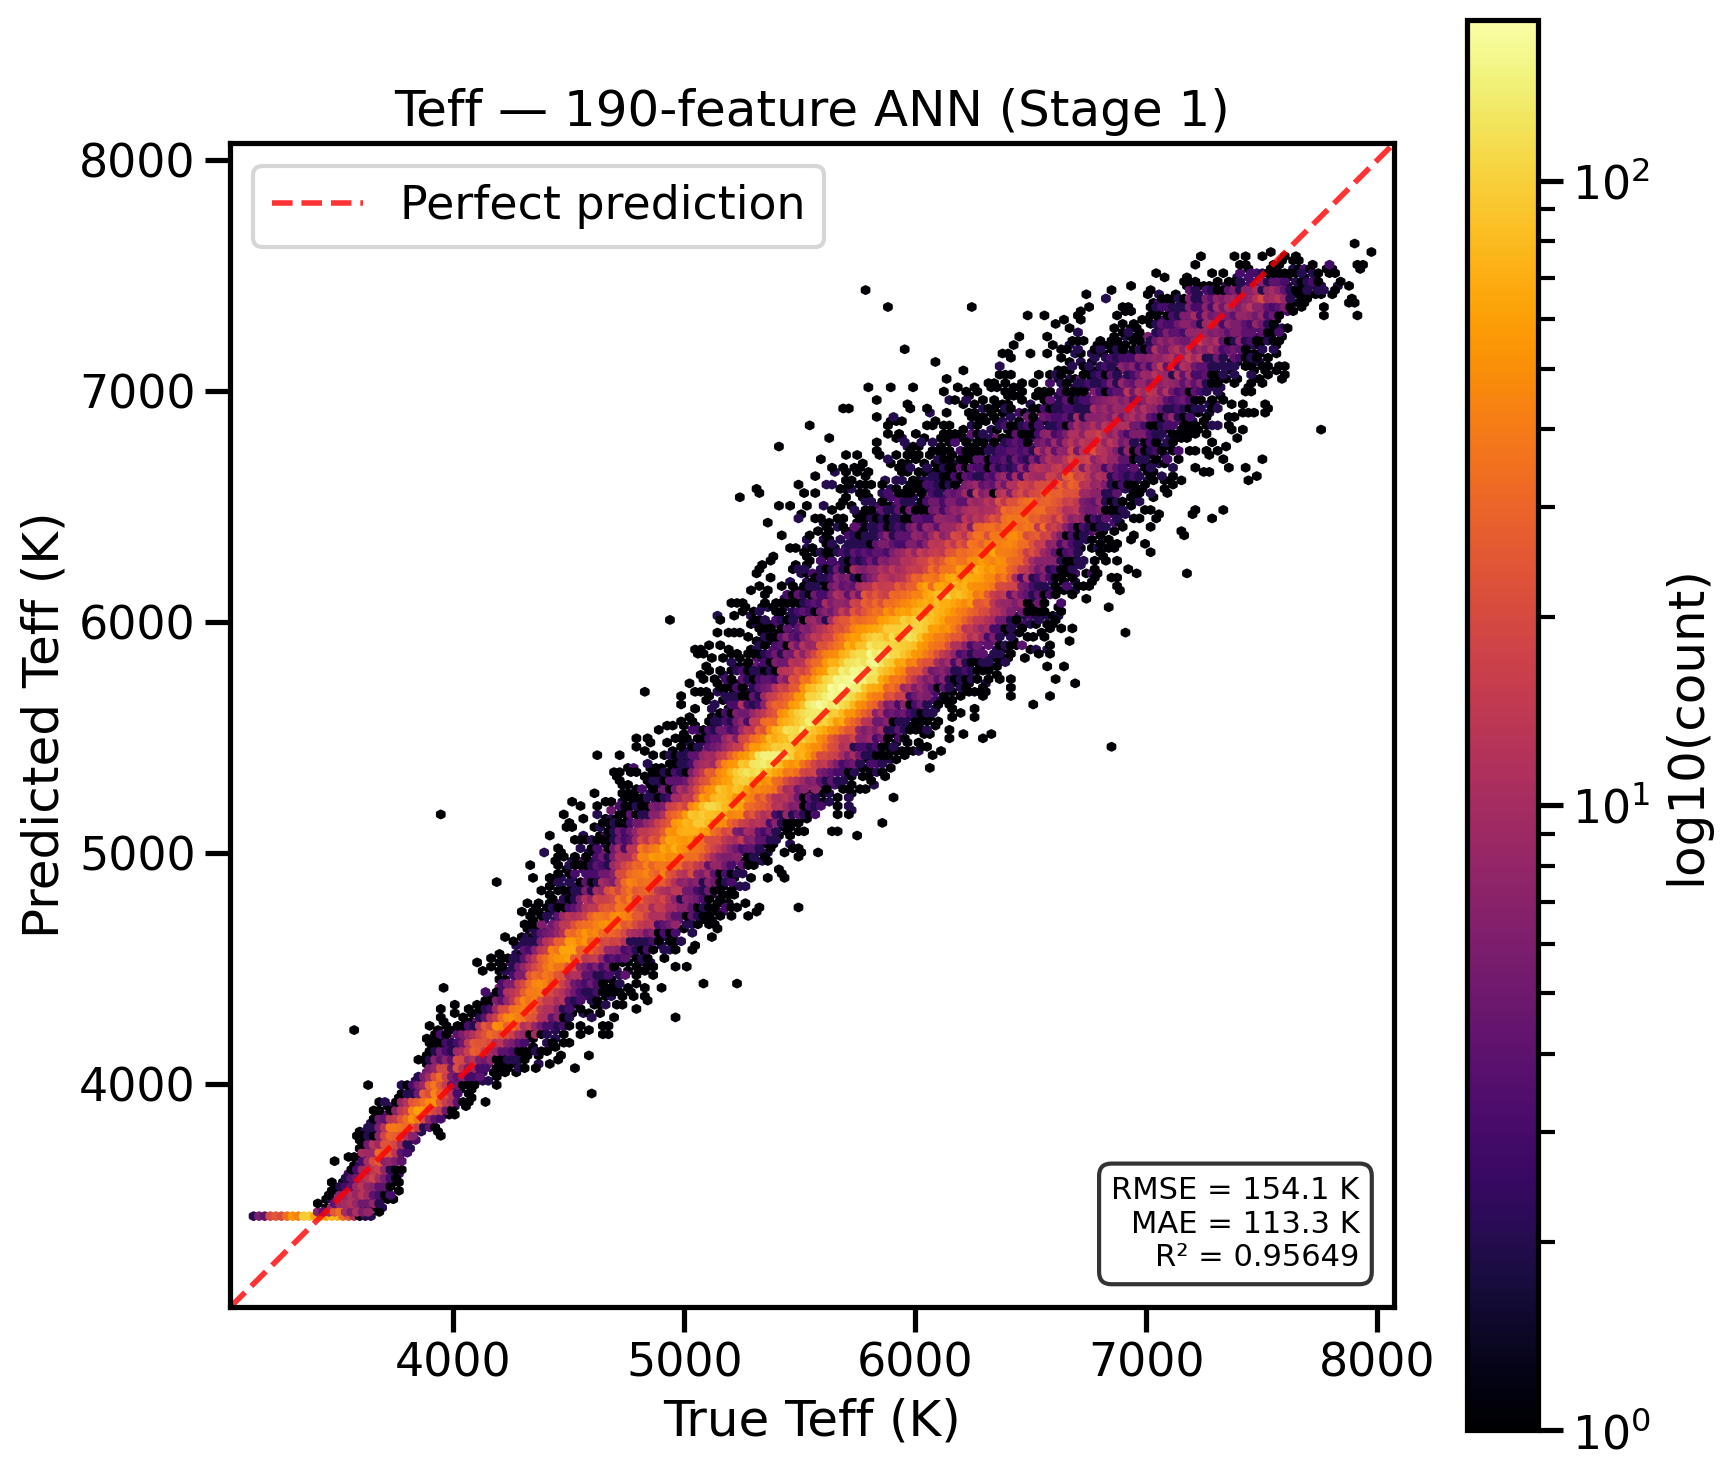

In [13]:
oto = RESULTS_DIR / 'one_to_one_plot.png'
if oto.exists():
    ipy_display(IPyImage(filename=str(oto), width=800))
else:
    fig, ax = plt.subplots(figsize=(9,8))
    hb = ax.hexbin(teff_true_K, teff_pred_K, gridsize=200, cmap='inferno', mincnt=1, bins='log')
    plt.colorbar(hb, ax=ax, label='log10(count)')
    lims = [min(teff_true_K.min(),teff_pred_K.min())-100, max(teff_true_K.max(),teff_pred_K.max())+100]
    ax.plot(lims, lims, 'r--', lw=2, alpha=0.8)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
    ax.set_xlabel('True Teff (K)'); ax.set_ylabel('Predicted Teff (K)')
    ax.set_title('Teff — 190-feature ANN')
    ax.text(0.97,0.03,f'RMSE={rmse_teff:.1f} K\nR²={r2_teff:.5f}',
            transform=ax.transAxes, fontsize=11, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))
    plt.tight_layout(); plt.show()

## 12. Residual Plots

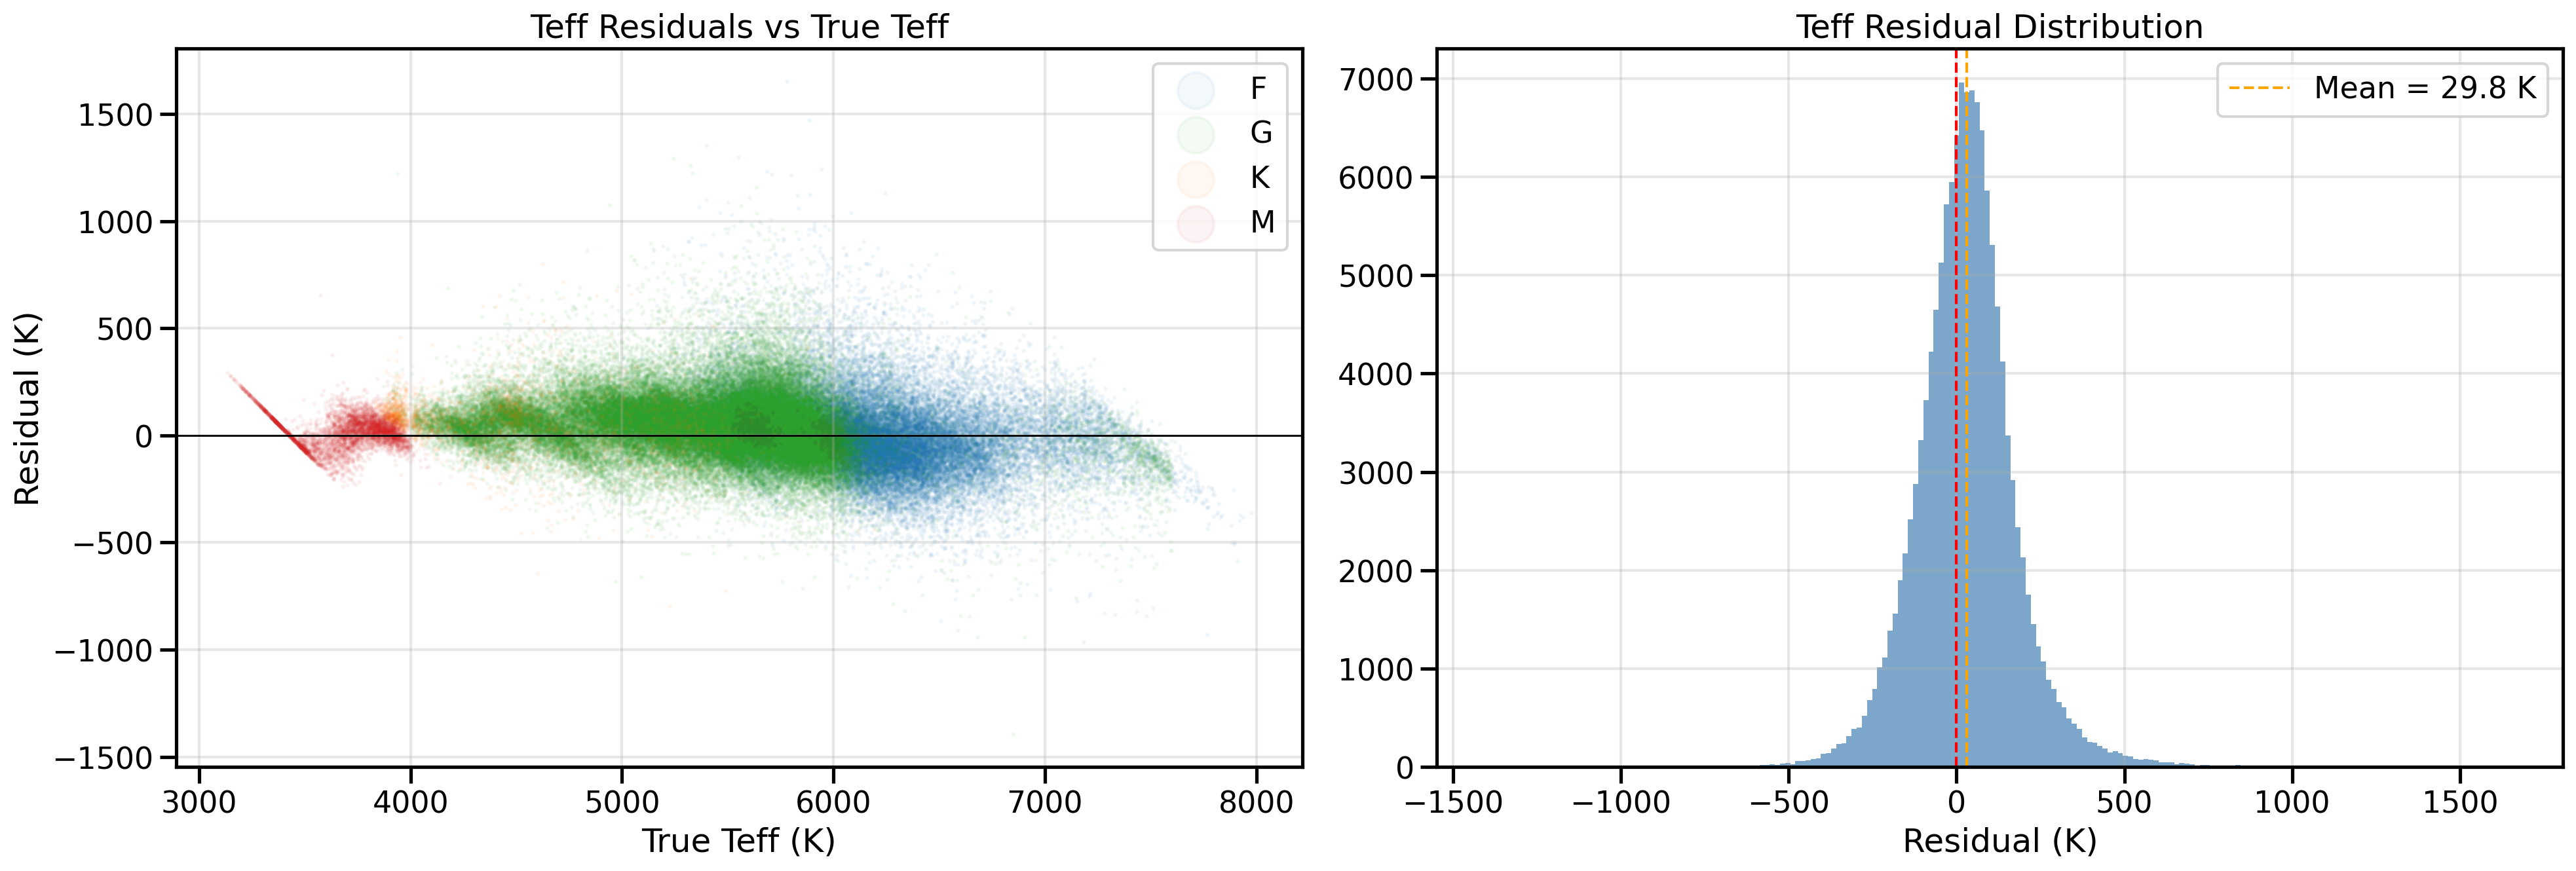

In [14]:
rp = RESULTS_DIR / 'residual_plots.png'
if rp.exists():
    ipy_display(IPyImage(filename=str(rp), width=1400))
else:
    res = teff_pred_K - teff_true_K
    colors_map = {'F':'#1f77b4','G':'#2ca02c','K':'#ff7f0e','M':'#d62728'}
    fig, axes = plt.subplots(1,2,figsize=(18,7))
    ax = axes[0]
    for stype in ['F','G','K','M']:
        mask = st_test == stype
        ax.scatter(teff_true_K[mask], res[mask], alpha=0.05, s=1, color=colors_map[stype], label=stype, rasterized=True)
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('True Teff (K)'); ax.set_ylabel('Residual (K)'); ax.set_title('Teff Residuals')
    ax.legend(markerscale=20); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.hist(res, bins=200, alpha=0.7, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', ls='--', lw=1.5)
    ax.axvline(np.mean(res), color='orange', ls='--', lw=1.5, label=f'Mean={np.mean(res):.1f} K')
    ax.set_xlabel('Residual (K)'); ax.set_title('Teff Residual Distribution'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 13. Saved Metrics

In [15]:
with open(METRICS_PATH) as f:
    metrics = json.load(f)
print(json.dumps(metrics, indent=2))

{
  "model": "teff_190_ann",
  "teff": {
    "rmse_K": 154.105,
    "mae_K": 113.333,
    "r2_K": 0.956487,
    "r2_log10": 0.962589
  },
  "training": {
    "best_epoch": 10,
    "total_epochs_run": 40,
    "n_train_augmented": 2163707,
    "n_val": 135664,
    "n_test": 135665,
    "n_features": 190,
    "n_color_features": 171,
    "n_absmag_features": 19,
    "augmentation_bin_width_K": 150.0
  },
  "per_type": {
    "F": {
      "teff_r2": 0.840492,
      "teff_rmse_K": 174.438
    },
    "G": {
      "teff_r2": 0.923678,
      "teff_rmse_K": 146.805
    },
    "K": {
      "teff_r2": 0.893438,
      "teff_rmse_K": 157.937
    },
    "M": {
      "teff_r2": 0.843319,
      "teff_rmse_K": 73.201
    }
  },
  "baseline_comparison": {
    "teff_171feat_r2": 0.965,
    "teff_171feat_rmse": 144.0,
    "this_r2": 0.95649,
    "this_rmse": 154.105,
    "delta_r2": -0.00851,
    "delta_rmse": 10.105
  }
}


## 14. Comparison with Baseline

In [16]:
print('=' * 68)
print('  COMPARISON — Teff')
print('=' * 68)
print(f'  {"171-feature ANN (baseline)":<40}  R²=0.96500  RMSE=144.0 K')
flag = 'IMPROVED' if r2_teff > 0.96500 else 'REGRESSED'
print(f'  {"190-feature ANN (this)":<40}  R²={r2_teff:.5f}  RMSE={rmse_teff:.1f} K'
      f'  ({r2_teff-0.96500:+.5f} R², {rmse_teff-144.0:+.1f} K)  {flag}')

  COMPARISON — Teff
  171-feature ANN (baseline)                R²=0.96500  RMSE=144.0 K
  190-feature ANN (this)                    R²=0.95649  RMSE=154.1 K  (-0.00851 R², +10.1 K)  REGRESSED
